# __Midterm Coding Project__
#### ___Ben Hornickle and Will Guerin___



In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import datetime

# __OMDB API__
To explore content related to films, we used the OMDB api, which provides a wealth of information about a movie's production data, ratings, and performance.

In [ ]:
api_key = 'b0259000'

# Function to find movie information
def movie_info(movie):
  url = f'http://www.omdbapi.com/?apikey={api_key}&'
  params = {'t': movie,
            'type': 'movie',
            'r': 'json'}
  r = requests.get(url, params = params)
  return r.json()


# __Importing Data__
The OMDB API itself does not have a ton of data built into it, rather it is a tool to find information about an inputted movie or television series. Therefore, in order to find information on a variety of different films, we compiled a list of over 300 films that we have seen or want to see in the near future which we will be analyzing with this project.

In [ ]:
# import movies as csv
movies_csv = pd.read_csv('/content/movies.csv', encoding='latin1')

In [ ]:
# Empty lists to store all the variables I want to find
titles = []
years = []
released_data = []
genres = []
runtimes = []
ratings = []
languages = []
votes = []
director = []
country = []
actors = []
imdb_scores = []
metascores = []
box_office = []
awards = []

# __Accessing OMDB__

For each movie in our list, we used the OMDB API to pull information on it's year of production, release date to the US, genre, runtime, age rating, language, number of IMDB votes, director, country of origin, IMDB score, metascore, US box office performance, awards information, and main actors.

In [ ]:
# Read through each movie in the movies csv
for movie_title in movies_csv['title']:
  # Call movie_info once per movie to avoid hitting API limit (1000 per day)
  info = movie_info(movie_title)

  # Check if the API call returned a valid response (movie could be found)
  # If so, fill the lists with the appropriate info, or None if it is not present
  if info and info.get('Response') == 'True':
    titles.append(movie_title)
    years.append(info.get('Year', None))
    released_data.append(info.get('Released', None))
    genres.append(info.get('Genre', None))
    runtimes.append(info.get('Runtime', None))
    ratings.append(info.get('Rated', None))
    languages.append(info.get('Language', None))
    votes.append(info.get('imdbVotes', None))
    director.append(info.get('Director', None))
    country.append(info.get('Country', None))
    imdb_scores.append(info.get('imdbRating', None))
    metascores.append(info.get('Metascore', None))
    box_office.append(info.get('BoxOffice', None))
    awards.append(info.get('Awards', None))
    actors.append(info.get('Actors', None))
  else:
    # If the movie info could not be retrieved, append None for all fields besides the title
    titles.append(movie_title)
    years.append(None)
    released_data.append(None)
    genres.append(None)
    runtimes.append(None)
    ratings.append(None)
    languages.append(None)
    votes.append(None)
    director.append(None)
    country.append(None)
    imdb_scores.append(None)
    metascores.append(None)
    box_office.append(None)
    awards.append(None)
    actors.append(None)

# __Creating the Data Frame__

To create the dataframe, we combined the various lists that contain all the different information about each movie from above into a dataframe "data"

A lot of cleaning and formatting was then required, which involed:

1. Converting 'Votes,' 'IMDB Score,' 'Metascore,' 'Box Office (usd),' and 'Runtime' to numeric values.

2. Converting 'Year' and 'Released' to datetime values.

3. Creating additional categorical and numeric columns.



In [ ]:
# Make the data into a dataframe for visualization
data = pd.DataFrame(
    {'Movie': titles,
     'Year': years,
     'Released': released_data,
     'Genre': genres,
     'Runtime (min)': runtimes,
     'Rating': ratings,
     'Votes': votes,
     'Director': director,
     'Actors': actors,
     'Country': country,
     'Language': languages,
     'IMDB Score': imdb_scores,
     'Metascore': metascores,
     'Box Office (usd)': box_office,
     'Awards': awards})

In [ ]:
# Clean up votes and make numeric
data['Votes'] = data['Votes'].str.replace(',', '', regex=False)
data['Votes'] = pd.to_numeric(data['Votes'], errors = 'coerce')

In [ ]:
# Make IMDB score numberic
data['IMDB Score'] = pd.to_numeric(data['IMDB Score'], errors = 'coerce')

In [ ]:
# Make metascores numeric, ignoring any missing entires
data['Metascore'] = pd.to_numeric(data['Metascore'], errors='coerce')

In [ ]:
# Clean and convert 'Box Office (usd)' to numeric
data['Box Office (usd)'] = data['Box Office (usd)'].str.replace('$', '', regex=False)
data['Box Office (usd)'] = data['Box Office (usd)'].str.replace(',', '', regex=False)
data['Box Office (usd)'] = pd.to_numeric(data['Box Office (usd)'], errors='coerce')

# Clean and convert 'Runtime (min)' to numeric
data['Runtime (min)'] = data['Runtime (min)'].str.replace(' min', '', regex=False)
data['Runtime (min)'] = pd.to_numeric(data['Runtime (min)'], errors='coerce')

In [ ]:
# Make year info into a datetime value
data['Year'] = pd.to_datetime(data['Year'], format='%Y')

In [ ]:
# Make release date into a datetime value
data['Released'] = pd.to_datetime(data['Released'], format='%d %b %Y', errors = 'coerce')

In [ ]:
# Group movies into decades for analysis
data['Decade'] = (data['Year'].dt.year // 10 * 10).astype(str) + 's'

In [ ]:
# Group runtimes into short, medium, and long movies
data['Categorical Length'] = 'Long'
data.loc[data['Runtime (min)'] < 90, 'Categorical Length'] = 'Short'
data.loc[(data['Runtime (min)'] >= 90) & (data['Runtime (min)'] < 150), 'Categorical Length'] = 'Medium'

In [ ]:
# Genre tells us a list of three genres, we want to seperate them
genre_split = data['Genre'].str.split(', ')

# Assign seperated genres to primary, secondary, and tertiary collumns
data['Primary Genre'] = genre_split.str[0]
data['Secondary Genre'] = genre_split.str[1].fillna('N/A')
data['Tertiary Genre'] = genre_split.str[2].fillna('N/A')

In [ ]:
# The genre collumn is no longer needed
data.drop(columns=['Genre'], inplace=True)

In [ ]:
# Seperate the list of languages
language_split = data['Language'].str.split(', ')

# Assign seperated languages to primary and secondary
data['Primary Language'] = language_split.str[0]
data['Secondary Lanuage'] = language_split.str[1].fillna('N/A')

# Determine if the film is offered in English
data['is_English'] = data['Language'].str.contains('English', case=False).fillna(False)

/tmp/ipykernel_1868/2242318701.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data['is_English'] = data['Language'].str.contains('English', case=False).fillna(False)


In [ ]:
# Seperate the list of actors
actors_split = data['Actors'].str.split(', ')

# Assign seperated actors to primary, secondary, and tertiary collumns
data['Primary Actor'] = actors_split.str[0]
data['Secondary Actor'] = actors_split.str[1].fillna('N/A')
data['Tertiary Actor'] = actors_split.str[2].fillna('N/A')

In [ ]:
# Group age ratings into whether or not it is appropriate for children
# Set the default as False (R, NC-17, Unrated)
data['is_Appropriate'] = False
# If the movie is G, PG, or PG-13, set to True
data.loc[data['Rating'].isin(['G', 'PG', 'PG-13']), 'is_Appropriate'] = True

In [ ]:
# Initialize 'Average Rating' using np.where for conditional assignment
# If Metascore does not exist, make average score IMDB * 10
# Otherwise, calculate the average of the twp
data['Average Rating'] = np.where(
    data['Metascore'].isna(),
    data['IMDB Score'] * 10,
    (data['IMDB Score'] * 10 + data['Metascore']) / 2
)

In [ ]:
# Initialize 'Difference in Rating'
data['Difference in Rating'] = abs(data['Metascore'] - data['IMDB Score'] * 10)

#__Exploratory Data Analysis__

With our data frame set up and all of our collumns ready to go, we then proceded to explore our data, walking through a variety of guiding questions to see which factors most influenced movie performance.

In [ ]:
# Display the data frame to make sure everything loaded in correctly
pd.set_option('display.max_rows', None)    # Show all rows
pd.set_option('display.max_columns', None) # Show all columns
data


,Movie,Year,Released,Runtime (min),Rating,Votes,Director,Actors,Country,Language,IMDB Score,Metascore,Box Office (usd),Awards,Decade,Categorical Length,Primary Genre,Secondary Genre,Tertiary Genre,Primary Language,Secondary Lanuage,is_English,Primary Actor,Secondary Actor,Tertiary Actor,is_Appropriate,Average Rating,Difference in Rating
0,Oldboy,2003-01-01,2003-11-21,120.0,R,710562.0,Park Chan-wook,"Choi Min-sik, Yoo Ji-tae, Kang Hye-jeong",South Korea,Korean,8.3,78.0,2458200.0,46 wins & 28 nominations total,2000.0s,Medium,Action,Drama,Mystery,Korean,N/A,False,Choi Min-sik,Yoo Ji-tae,Kang Hye-jeong,False,80.5,5.0
1,Memories of Murder,2003-01-01,2003-05-02,131.0,Not Rated,262200.0,Bong Joon Ho,"Song Kang-ho, Kim Sang-kyung, Kim Roe-ha",South Korea,"Korean, English",8.1,82.0,15357.0,34 wins & 13 nominations total,2000.0s,Medium,Crime,Drama,Mystery,Korean,English,True,Song Kang-ho,Kim Sang-kyung,Kim Roe-ha,False,81.5,1.0
2,Lady Vengeance,2005-01-01,2005-07-29,115.0,R,90136.0,Park Chan-wook,"Lee Yeong-ae, Choi Min-sik, Yea-young Kwon",South Korea,"Korean, English, Japanese",7.5,75.0,211667.0,13 wins & 14 nominations total,2000.0s,Medium,Crime,Drama,Thriller,Korean,English,True,Lee Yeong-ae,Choi Min-sik,Yea-young Kwon,False,75.0,0.0
3,Sympathy for Mr. Vengeance,2002-01-01,2002-03-29,129.0,R,80662.0,Park Chan-wook,"Song Kang-ho, Shin Ha-kyun, Bae Doona",South Korea,"Korean, Korean Sign",7.5,59.0,45289.0,7 wins & 9 nominations total,2000.0s,Medium,Crime,Drama,Thriller,Korean,Korean Sign,False,Song Kang-ho,Shin Ha-kyun,Bae Doona,False,67.0,16.0
4,No Other Choice,2025-01-01,2026-01-16,139.0,R,45085.0,Park Chan-wook,"Lee Byung-hun, Son Ye-jin, Woo Seung Kim","South Korea, France","Korean, English",7.6,86.0,9950355.0,19 wins & 102 nominations total,2020.0s,Medium,Comedy,Crime,Drama,Korean,English,True,Lee Byung-hun,Son Ye-jin,Woo Seung Kim,False,81.0,10.0
5,I Saw The Devil,2010-01-01,2010-08-12,144.0,Not Rated,163662.0,Kim Jee-woon,"Lee Byung-hun, Choi Min-sik, Jeon Gook-hwan",South Korea,Korean,7.8,67.0,129210.0,17 wins & 21 nominations total,2010.0s,Medium,Action,Thriller,N/A,Korean,N/A,False,Lee Byung-hun,Choi Min-sik,Jeon Gook-hwan,False,72.5,11.0
6,"Black Coal, Thin Ice",2014-01-01,2014-03-21,110.0,Not Rated,10279.0,Yi'nan Diao,"Fan Liao, Lun-Mei Gwei, Xuebing Wang","China, Hong Kong",Mandarin,6.7,70.0,NaN,30 wins & 48 nominations total,2010.0s,Medium,Crime,Drama,Mystery,Mandarin,N/A,False,Fan Liao,Lun-Mei Gwei,Xuebing Wang,False,68.5,3.0
7,"The Gangster, The Cop, The Devil",2019-01-01,2019-05-15,109.0,Not Rated,32511.0,Lee Won-tae,"Ma Dong-seok, Kim Mu-yeol, Kim Sungkyu",South Korea,"Korean, English",7.0,65.0,216494.0,1 win & 2 nominations total,2010.0s,Medium,Action,Crime,Thriller,Korean,English,True,Ma Dong-seok,Kim Mu-yeol,Kim Sungkyu,False,67.5,5.0
8,Ichi The Killer,2001-01-01,2001-12-22,129.0,R,62567.0,Takashi Miike,"Tadanobu Asano, Nao Ômori, Shin'ya Tsukamoto",Japan,"Japanese, Cantonese, English",6.9,55.0,20285.0,6 wins & 4 nominations total,2000.0s,Medium,Action,Crime,Drama,Japanese,Cantonese,True,Tadanobu Asano,Nao Ômori,Shin'ya Tsukamoto,False,62.0,14.0
9,Battle Royale,2000-01-01,2000-12-16,114.0,Not Rated,206168.0,Kinji Fukasaku,"Tatsuya Fujiwara, Aki Maeda, Tarô Yamamoto",Japan,"Japanese, English",7.5,81.0,NaN,7 wins & 8 nominations total,2000.0s,Medium,Action,Drama,Thriller,Japanese,English,True,Tatsuya Fujiwara,Aki Maeda,Tarô Yamamoto,False,78.0,6.0


In [ ]:
# Create a clone indexed by release date in case it is of interest to explore
release_date_indexed_data = data.set_index('Released')

# Question 1: Which variables are most correlated with box office performance in the US?

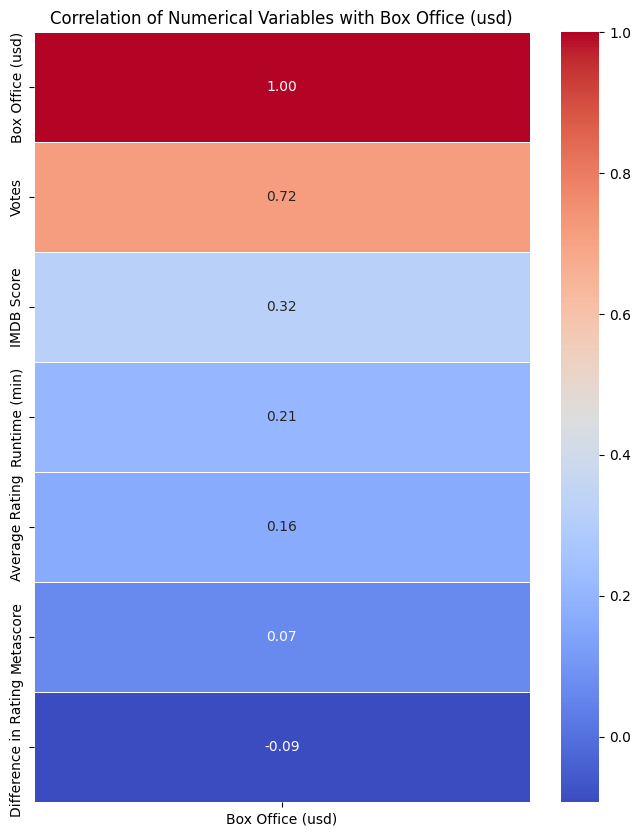

In [ ]:
# Subset the data for only the numerical columns to find correlation
numerical_cols = data.select_dtypes(include=np.number).columns
correlation_matrix = data[numerical_cols].corr()

# Get correlations with 'Box Office (usd)' and sort them
box_office_corr = correlation_matrix[['Box Office (usd)']].sort_values(by='Box Office (usd)', ascending=False)

# Plot as a heatmap
plt.figure(figsize=(8, 10))
sns.heatmap(box_office_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation of Numerical Variables with Box Office (usd)')
plt.show()

# Question 2: How do movies perform across different primary actors?

In [ ]:
# Find the counts of each primary actor
actor_counts = data['Primary Actor'].value_counts()

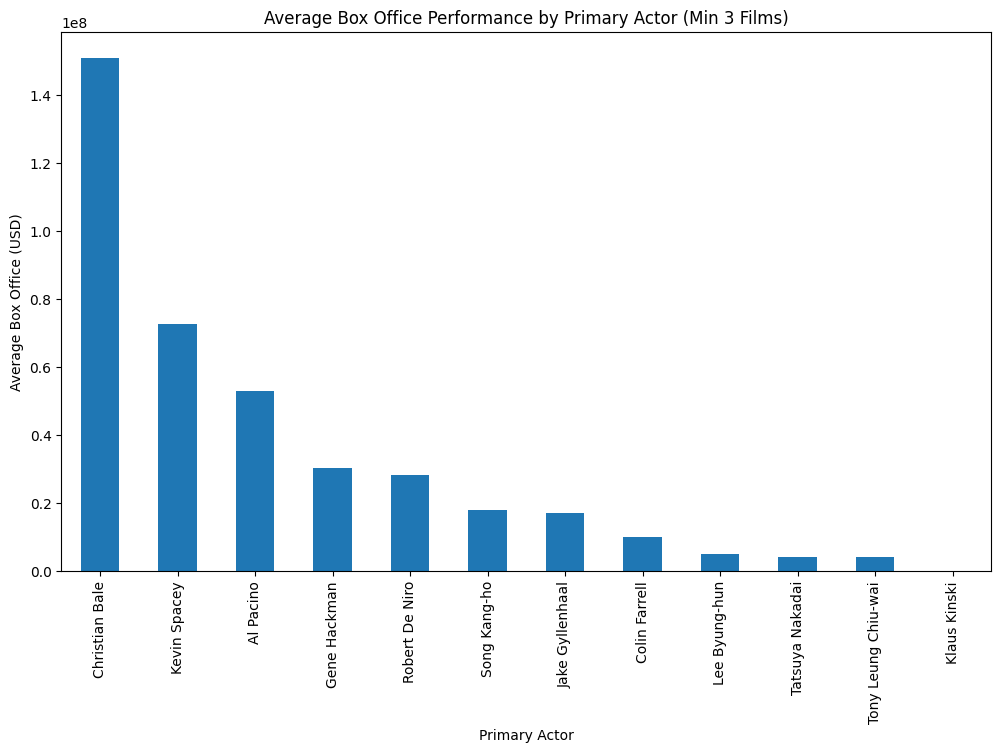

In [ ]:
# Find the actors who are the primary actors in at least 3 films
top_actors = actor_counts[actor_counts >= 3].index

# Subset the data in the main dataset to these actors, and average their box office
average_box_office = data[data['Primary Actor'].isin(top_actors)].groupby('Primary Actor')['Box Office (usd)'].mean().sort_values(ascending=False)

# Plot the data
plt.figure(figsize=(12, 7))
average_box_office.plot(kind = 'bar')
plt.title('Average Box Office Performance by Primary Actor (Min 3 Films)')
plt.xlabel('Primary Actor')
plt.ylabel('Average Box Office (USD)')
plt.show()

# Question 3: How do the movies of different directors perform against each other?

In [ ]:
# Find the counts of each primary actor
director_counts = data['Director'].value_counts()


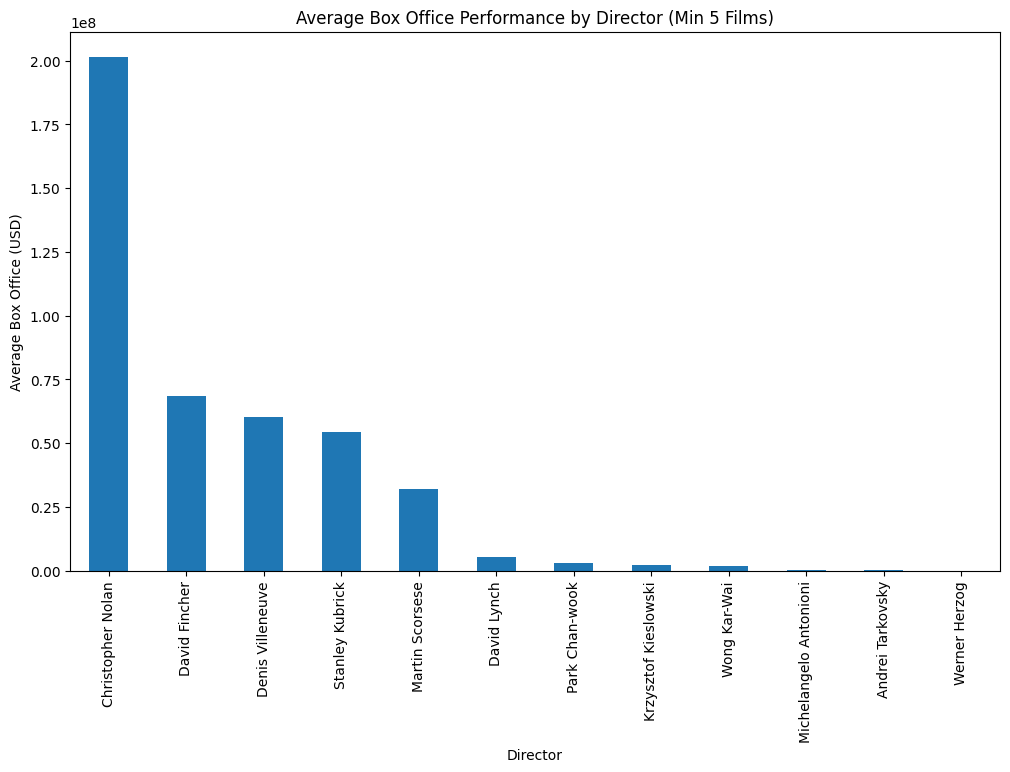

In [ ]:
# Find the directors who have directed at least 5 films on the list
top_directors = director_counts[director_counts >= 5].index

# Subset the data in the main dataset to these directors, and average their box office
average_box_office_director = data[data['Director'].isin(top_directors)].groupby('Director')['Box Office (usd)'].mean().sort_values(ascending=False)

# Plot the data
plt.figure(figsize=(12, 7))
average_box_office_director.plot(kind = 'bar')
plt.title('Average Box Office Performance by Director (Min 5 Films)')
plt.xlabel('Director')
plt.ylabel('Average Box Office (USD)')
plt.show()

# Question 4: How does the average rating of films vary over time?

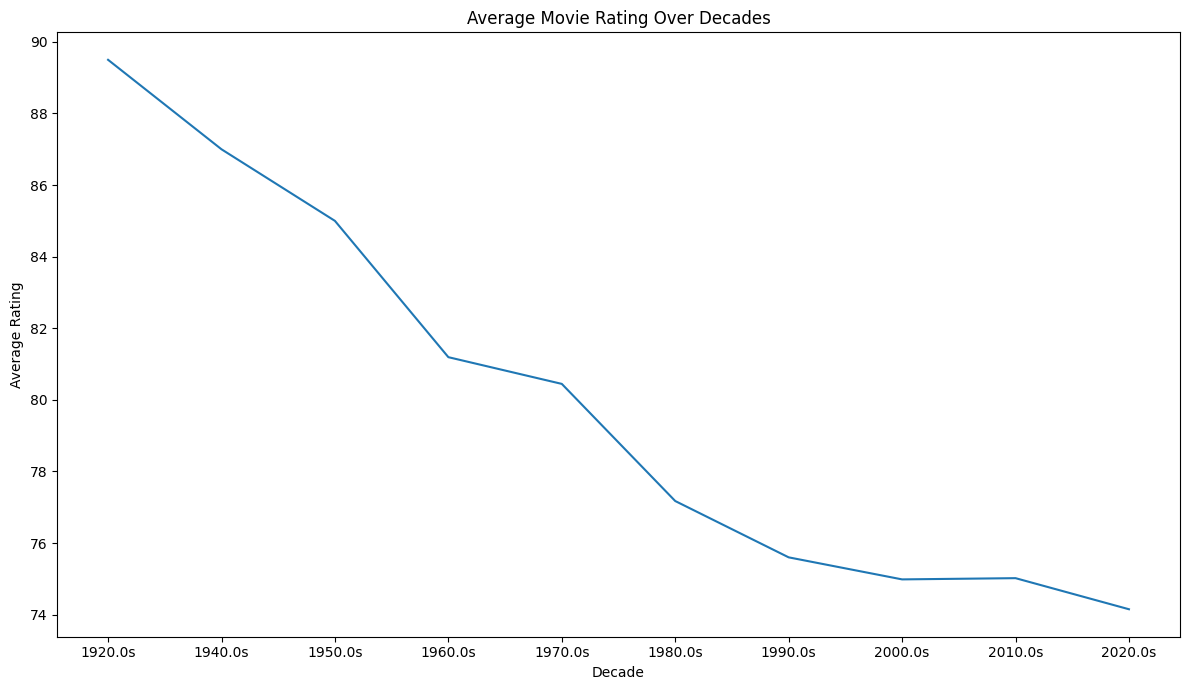

In [ ]:
# Calculate the average 'Average Rating' for each decade
average_rating_by_decade = data.groupby('Decade')['Average Rating'].mean().reset_index()

# Sort the decades chronologically
average_rating_by_decade = average_rating_by_decade.sort_values(by='Decade')

# Plot the data
plt.figure(figsize=(12, 7))
sns.lineplot(x='Decade', y='Average Rating', data=average_rating_by_decade)
plt.title('Average Movie Rating Over Decades')
plt.xlabel('Decade')
plt.ylabel('Average Rating')
plt.tight_layout()
plt.show()

# Question 5: How does whether or not a film is offered in english affect its box office, average rating, and total votes performance?

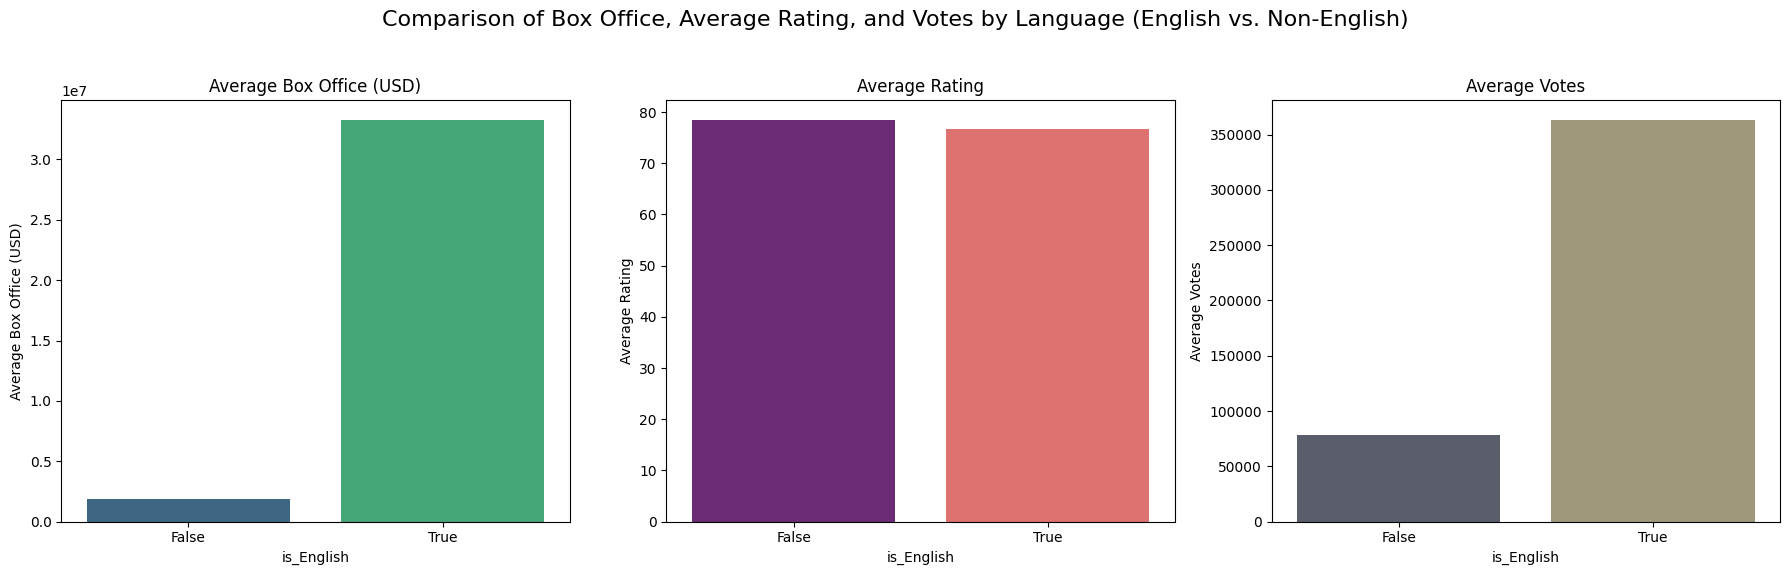

In [ ]:
# Group by 'is_English' and calculate the mean for 'Box Office (usd)', 'Average Rating', and 'Votes'
english_vs_non_english = data.groupby('is_English')[['Box Office (usd)', 'Average Rating', 'Votes']].mean()

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparison of Box Office, Average Rating, and Votes by Language (English vs. Non-English)', fontsize=16)

# Plot for Box Office (usd)
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Box Office (usd)'], ax=axes[0], hue=english_vs_non_english.index, palette='viridis', legend=False)
axes[0].set_title('Average Box Office (USD)')
axes[0].set_xlabel('is_English')
axes[0].set_ylabel('Average Box Office (USD)')
axes[0].set_xticks([0, 1], ['False', 'True'])

# Plot for Average Rating
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Average Rating'], ax=axes[1], hue=english_vs_non_english.index, palette='magma', legend=False)
axes[1].set_title('Average Rating')
axes[1].set_xlabel('is_English')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticks([0, 1], ['False', 'True'])

# Plot for Votes
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Votes'], ax=axes[2], hue=english_vs_non_english.index, palette='cividis', legend=False)
axes[2].set_title('Average Votes')
axes[2].set_xlabel('is_English')
axes[2].set_ylabel('Average Votes')
axes[2].set_xticks([0, 1], ['False', 'True'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Question 6: How does whether or not a film is appropriate for children affect its box office, rating, and popularity performance?


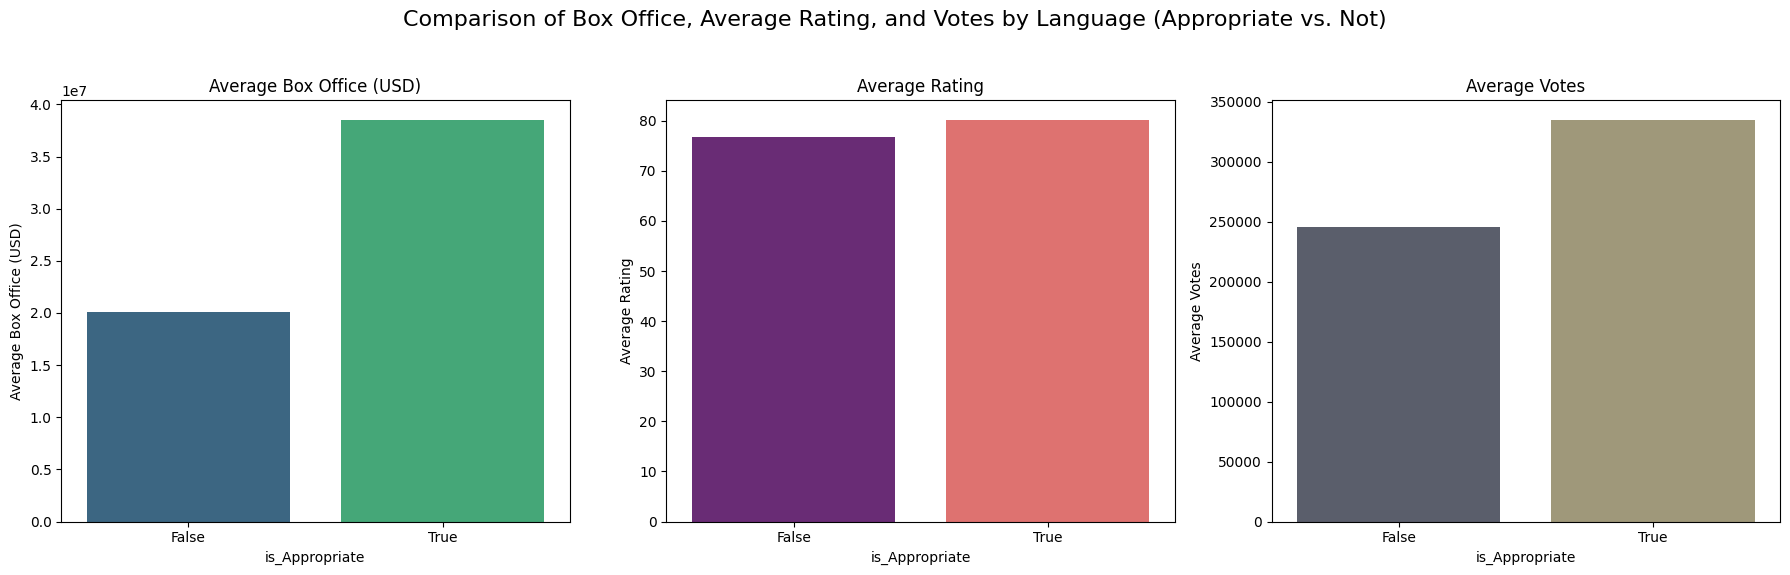

In [ ]:
# Group by 'is_Appropriate' and calculate the mean for 'Box Office (usd)', 'Average Rating', and 'Votes'
english_vs_non_english = data.groupby('is_Appropriate')[['Box Office (usd)', 'Average Rating', 'Votes']].mean()

# Plotting the results
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparison of Box Office, Average Rating, and Votes by Language (Appropriate vs. Not)', fontsize=16)

# Plot for Box Office (usd)
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Box Office (usd)'], ax=axes[0], hue=english_vs_non_english.index, palette='viridis', legend=False)
axes[0].set_title('Average Box Office (USD)')
axes[0].set_xlabel('is_Appropriate')
axes[0].set_ylabel('Average Box Office (USD)')
axes[0].set_xticks([0, 1], ['False', 'True'])

# Plot for Average Rating
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Average Rating'], ax=axes[1], hue=english_vs_non_english.index, palette='magma', legend=False)
axes[1].set_title('Average Rating')
axes[1].set_xlabel('is_Appropriate')
axes[1].set_ylabel('Average Rating')
axes[1].set_xticks([0, 1], ['False', 'True'])

# Plot for Votes
sns.barplot(x=english_vs_non_english.index, y=english_vs_non_english['Votes'], ax=axes[2], hue=english_vs_non_english.index, palette='cividis', legend=False)
axes[2].set_title('Average Votes')
axes[2].set_xlabel('is_Appropriate')
axes[2].set_ylabel('Average Votes')
axes[2].set_xticks([0, 1], ['False', 'True'])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Question 7: Do higher rated movies attract more votes on IMDb?


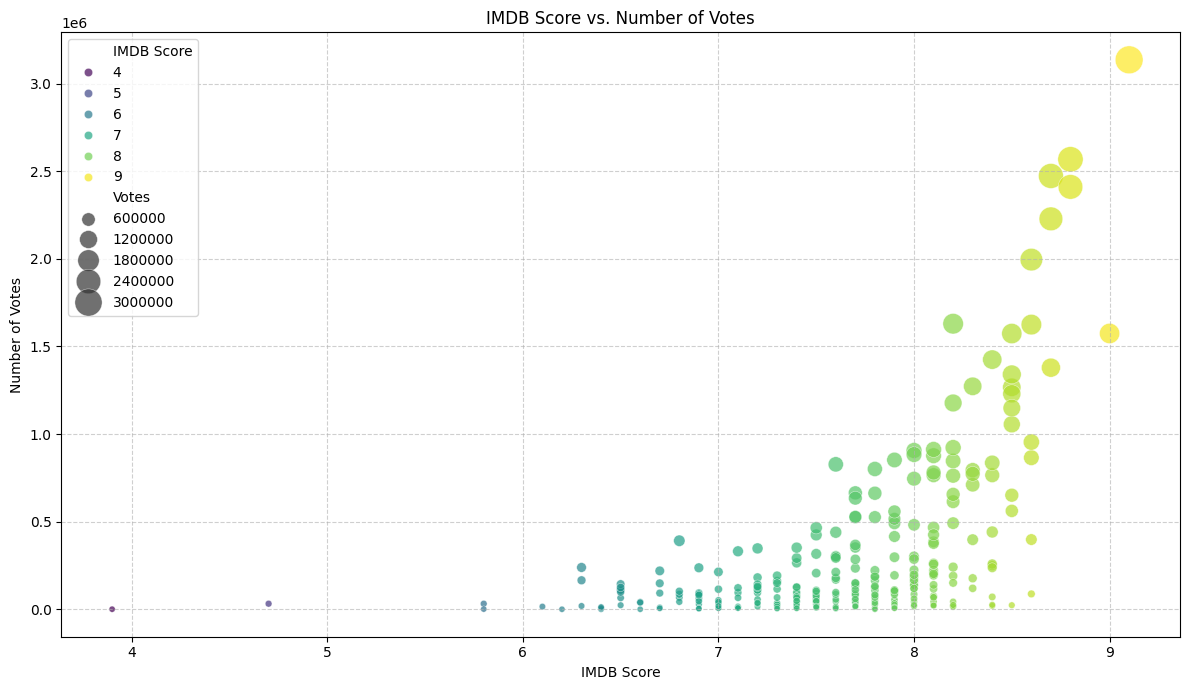

In [ ]:
plt.figure(figsize=(12, 7))
# Make a scatter plot of IMDB score against Votes
sns.scatterplot(x='IMDB Score', y='Votes', data=data, hue='IMDB Score', palette='viridis', size='Votes', sizes=(20, 400), alpha=0.7)
# Format the graph nicely
plt.title('IMDB Score vs. Number of Votes')
plt.xlabel('IMDB Score')
plt.ylabel('Number of Votes')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 8: General Correlation Matrix



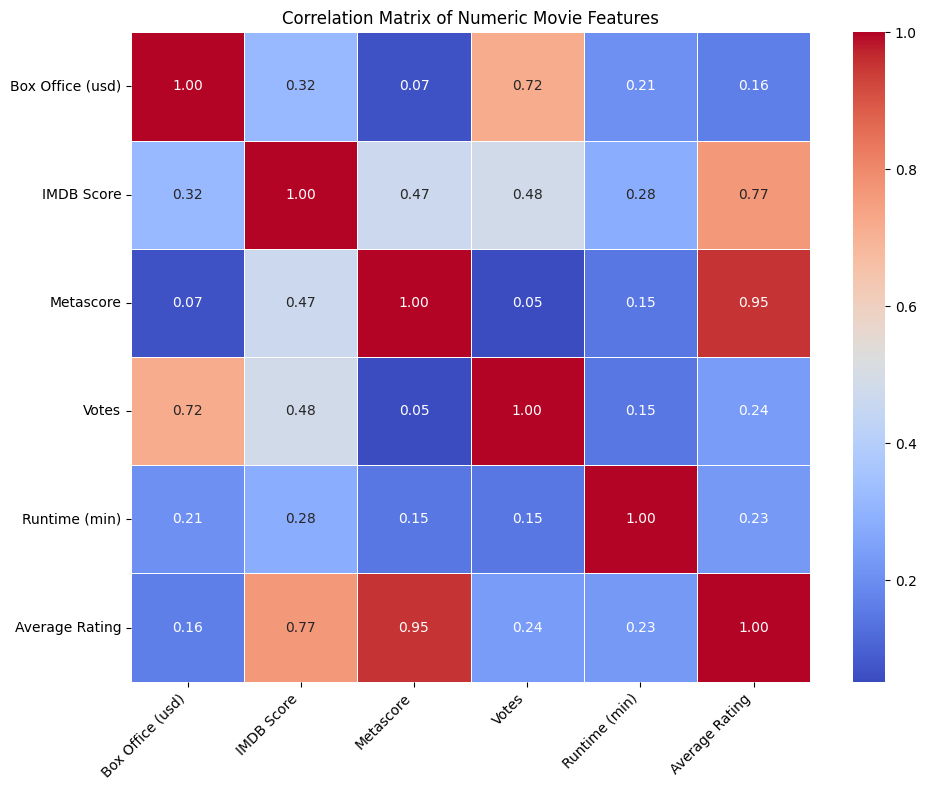

In [ ]:
# Identify the numeric collumns
numeric_cols = ['Box Office (usd)', 'IMDB Score', 'Metascore', 'Votes', 'Runtime (min)', 'Average Rating']
# Find their correlations and store them
correlation_matrix = data[numeric_cols].corr()

# Create a heatmap of the correlations
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
# Format the graph nicely
plt.title('Correlation Matrix of Numeric Movie Features')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#

# Question 9: Do critics and audiences agree on film quality, and which films divide them most?


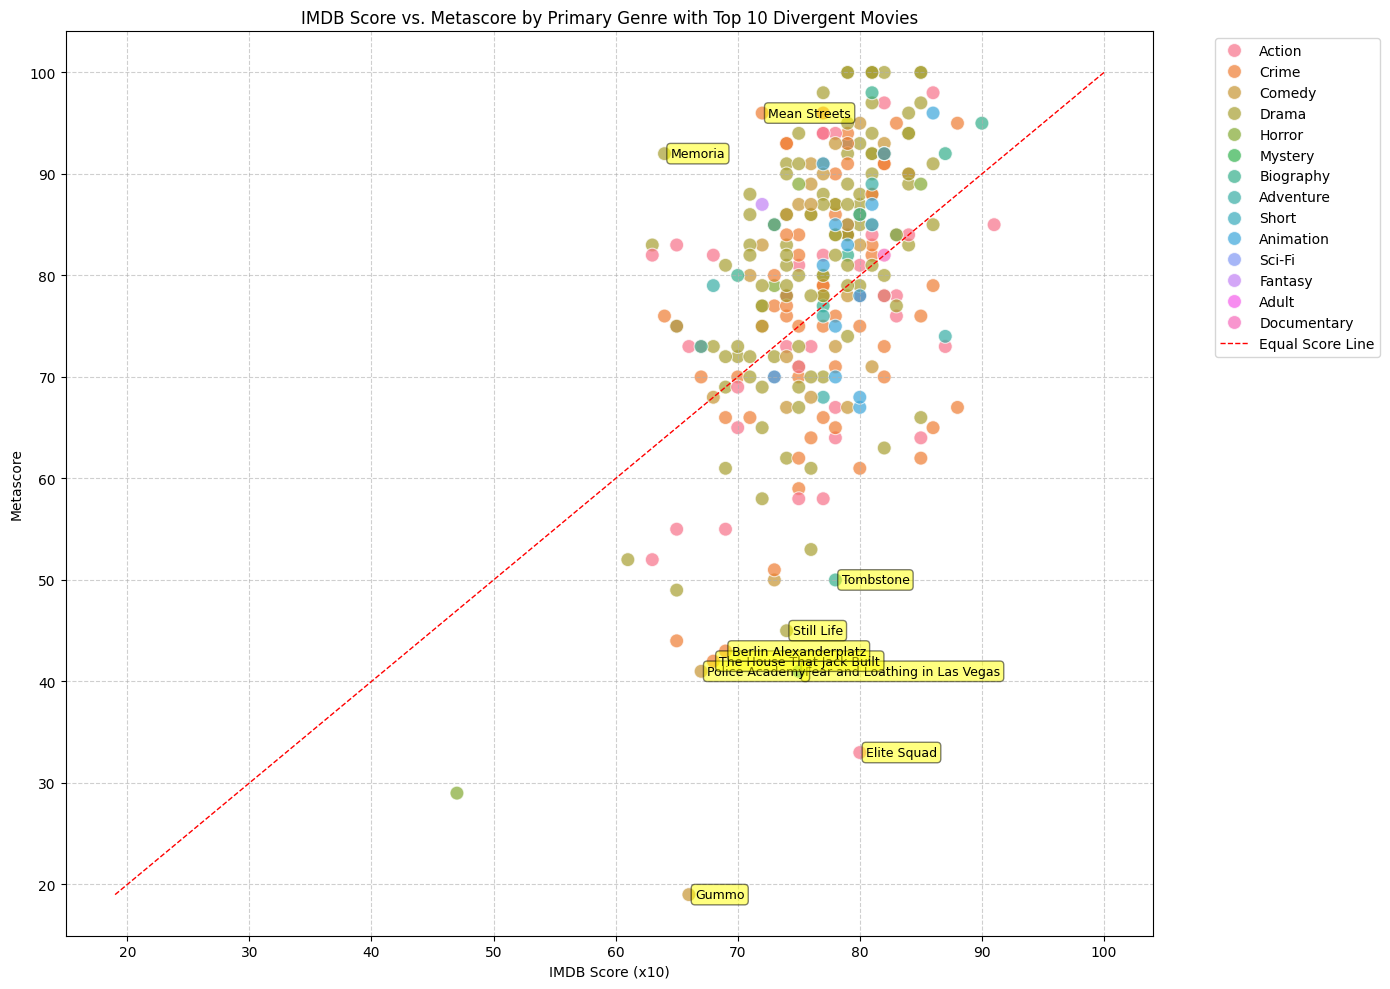

In [ ]:
data['IMDB Score (x10)'] = data['IMDB Score'] * 10

plt.figure(figsize=(14, 10))
sns.scatterplot(x='IMDB Score (x10)', y='Metascore', hue='Primary Genre', data=data, s=100, alpha=0.7)

# Add a diagonal reference line (x=y)
min_score = min(data['IMDB Score (x10)'].min(), data['Metascore'].min())
max_score = max(data['IMDB Score (x10)'].max(), data['Metascore'].max())
plt.plot([min_score, max_score], [min_score, max_score], color='red', linestyle='--', linewidth=1, label='Equal Score Line')

# Identify the top 10 movies with the highest 'Difference in Rating'
top_10_divergent_movies = data.nlargest(10, 'Difference in Rating')

# Label the top 10 movies on the plot
for i, row in top_10_divergent_movies.iterrows():
    plt.text(row['IMDB Score (x10)'] + 0.5, row['Metascore'], row['Movie'], fontsize=9, ha='left', va='center', bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5))

# Format the graph nicely
plt.title('IMDB Score vs. Metascore by Primary Genre with Top 10 Divergent Movies')
plt.xlabel('IMDB Score (x10)')
plt.ylabel('Metascore')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 10: Does Being an English-Language Film Affect Box Office Performance, Independent of How Well-Rated it is?

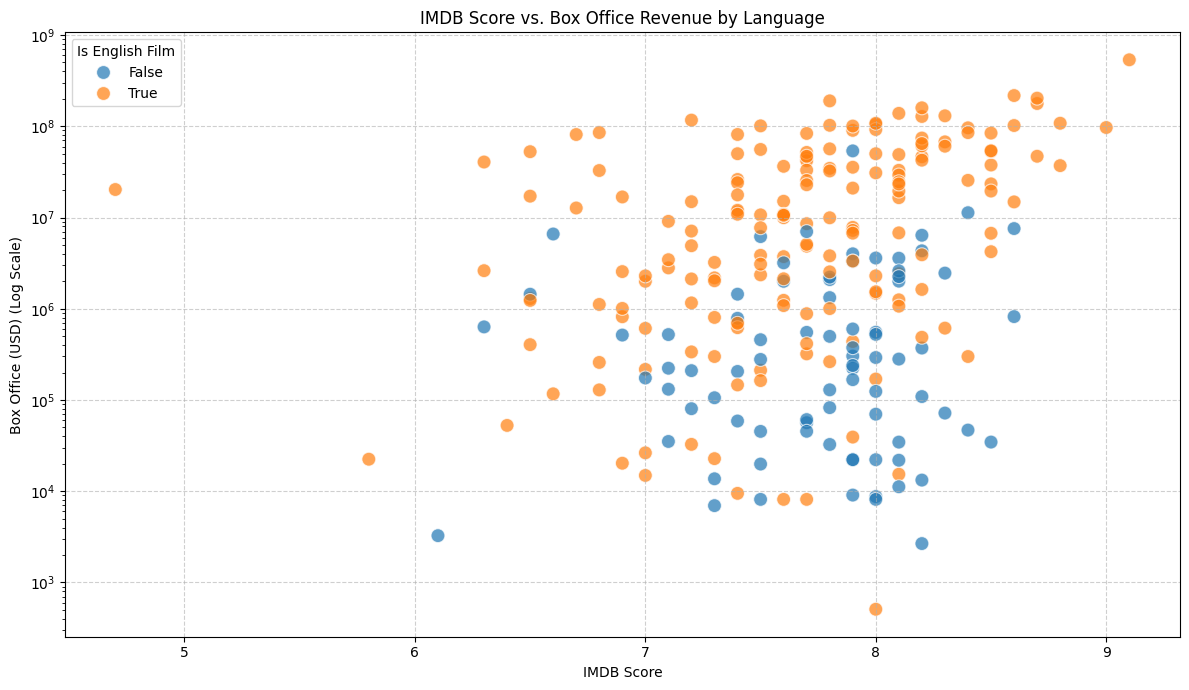

In [ ]:
# Graph IMDB score against box office, hue by english-language or not.
plt.figure(figsize=(12, 7))
sns.scatterplot(x='IMDB Score', y='Box Office (usd)', hue='is_English', data=data, s=100, alpha=0.7)
# Log the box office to acocunt for outliers
plt.yscale('log')
# Graph it
plt.title('IMDB Score vs. Box Office Revenue by Language')
plt.xlabel('IMDB Score')
plt.ylabel('Box Office (USD) (Log Scale)')
plt.legend(title='Is English Film')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 11: How does a film's conflicted status with the audience's relate to its box office performance?

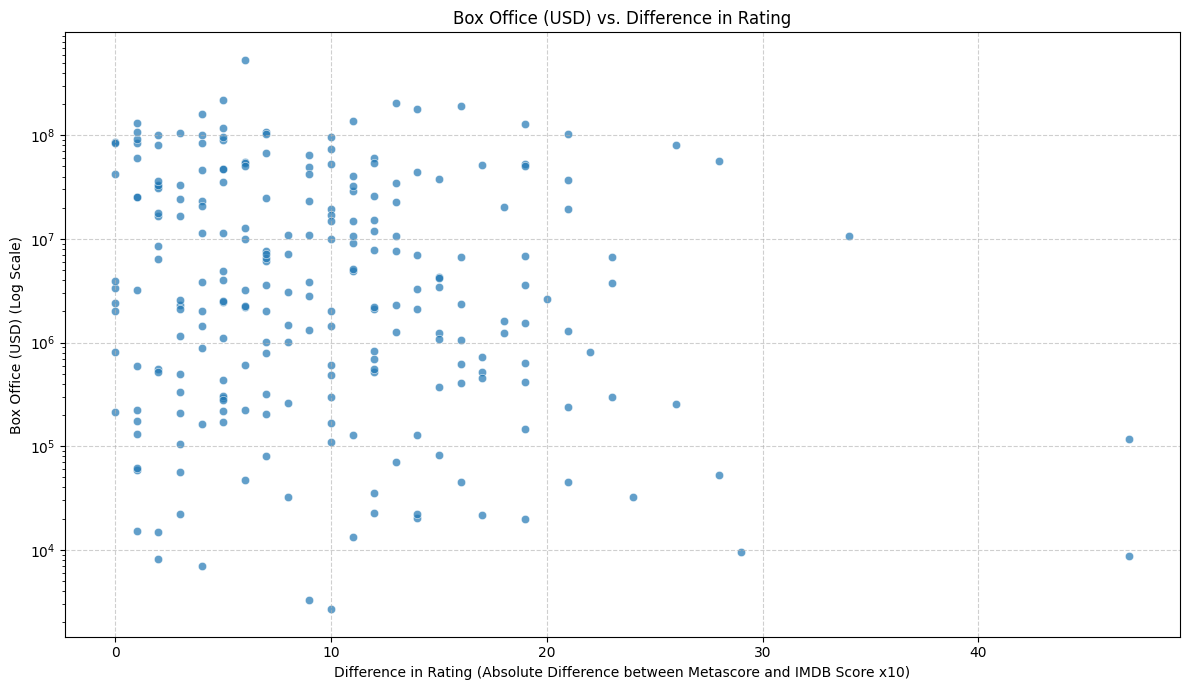

In [ ]:
# Make a scatter plot relating difference in rating against box office performancxe
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Difference in Rating', y='Box Office (usd)', data=data, sizes=(20, 400), alpha=0.7)
# Apply log to box office to account for outliers
plt.yscale('log')
# Format the graph nicely
plt.title('Box Office (USD) vs. Difference in Rating')
plt.xlabel('Difference in Rating (Absolute Difference between Metascore and IMDB Score x10)')
plt.ylabel('Box Office (USD) (Log Scale)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Question 12: Have movies gotten longer or shorter over time typically?

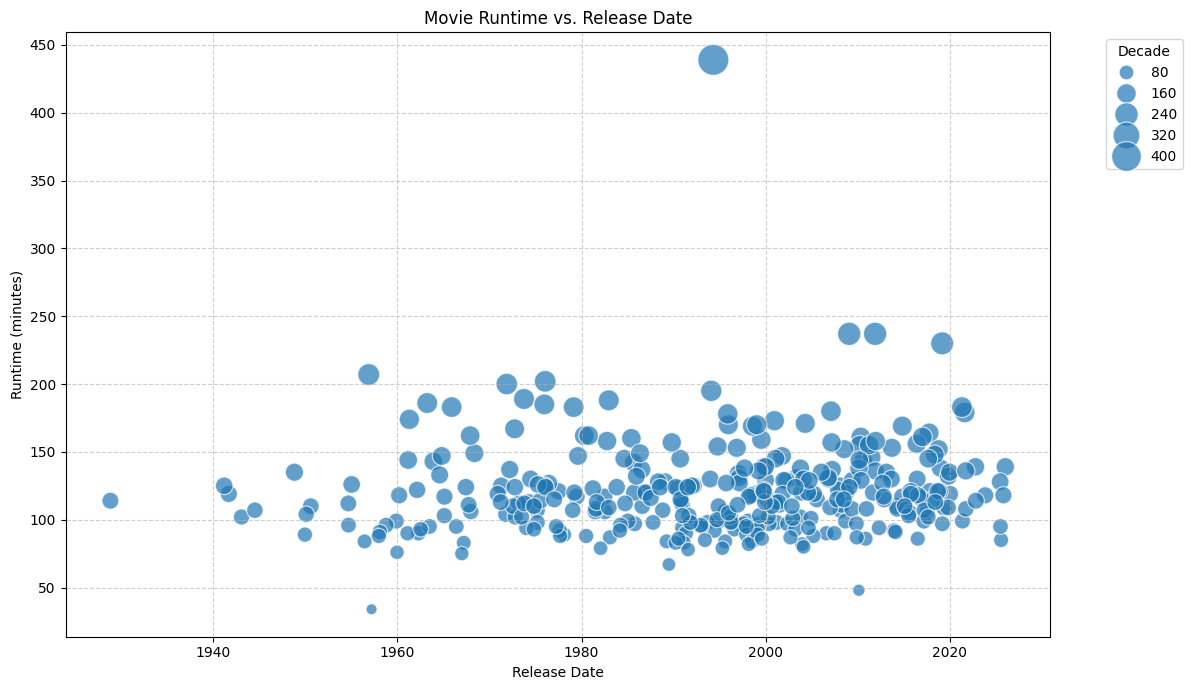

In [ ]:
# Make a scatter plot of release date against runtime
plt.figure(figsize=(12, 7))
sns.scatterplot(x='Released', y='Runtime (min)', data=data, size='Runtime (min)', sizes=(50, 500), alpha=0.7)
# Format the graph
plt.title('Movie Runtime vs. Release Date')
plt.xlabel('Release Date')
plt.ylabel('Runtime (minutes)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Decade', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Thank you!

For thorough analysis of our findings and executive summary, as well as more detailed explanation of the different goals and variables, see the attached README file.